In [2]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

# 1. Bayesian Regression

### Generating and Visualizing the Dataset

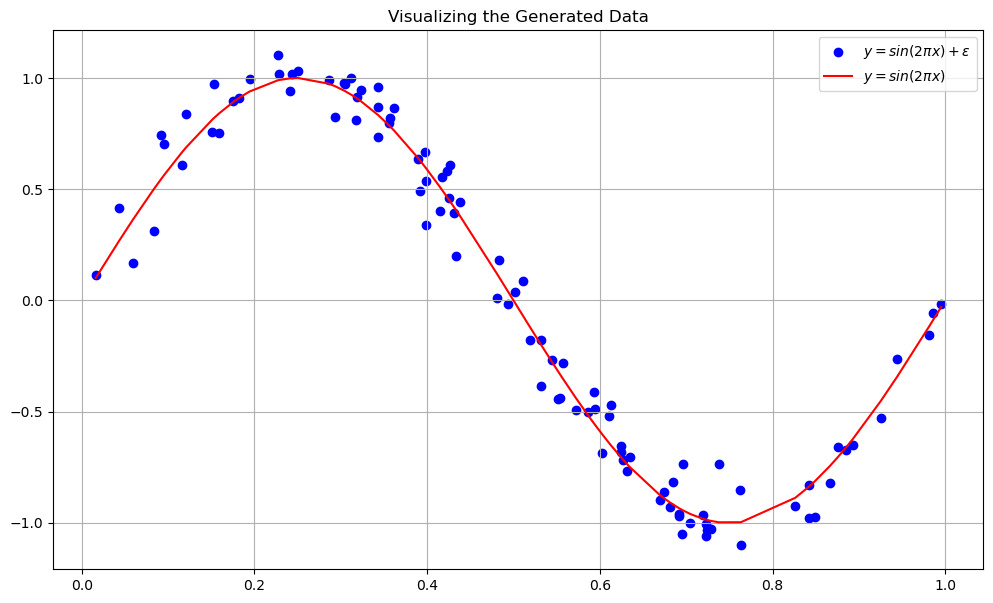

In [3]:
# Seeding.
np.random.seed(123)

# Generating the dataset.
N = 100 # Number of Samples.
# Sampling random uniform samples.
x = np.random.uniform(size = N).reshape(-1,1)
# Generating the corresponding target values.
t = np.sin(2*np.pi*x) + np.random.normal(loc = 0 , scale = 0.1 , size = x.shape)

# Visualizing the Dataset
x_sorted = np.sort(x.flatten())
plt.figure(figsize = (12 , 7))
plt.title("Visualizing the Generated Data")
plt.scatter(x , t , c = 'b' , label = f'$y = sin(2\\pi x) + \\epsilon$')
plt.plot(x_sorted , np.sin(2*np.pi*x_sorted) , 'r-' , label = f'$y = sin(2\\pi x)$')
plt.grid()
plt.legend()
plt.show()


In [4]:
# Ceneters and Scale factors of the Gaussian Basis Functions
mu = np.linspace(0 , 1 , 24).reshape(-1,1)
sigma = mu[1][0] - mu[0][0]

# Function to create the feature vector.
def create_feature_vector(x , mu = mu, sigma = sigma):
    phi = np.exp(-(mu - x)**2/(2*sigma**2))
    phi = np.insert(phi , 0 , 1)
    return phi.reshape(-1,1)



### Sequential Bayesian Update for Mean and Variance. 
- $S_N^{-1} = S_{N-1}^{-1} + \beta \phi(x_i) \phi(x_i)^T$
- $m_N = S_N(S_{N-1}^{-1}m_{N-1} + t_i \beta \phi(x_i))$

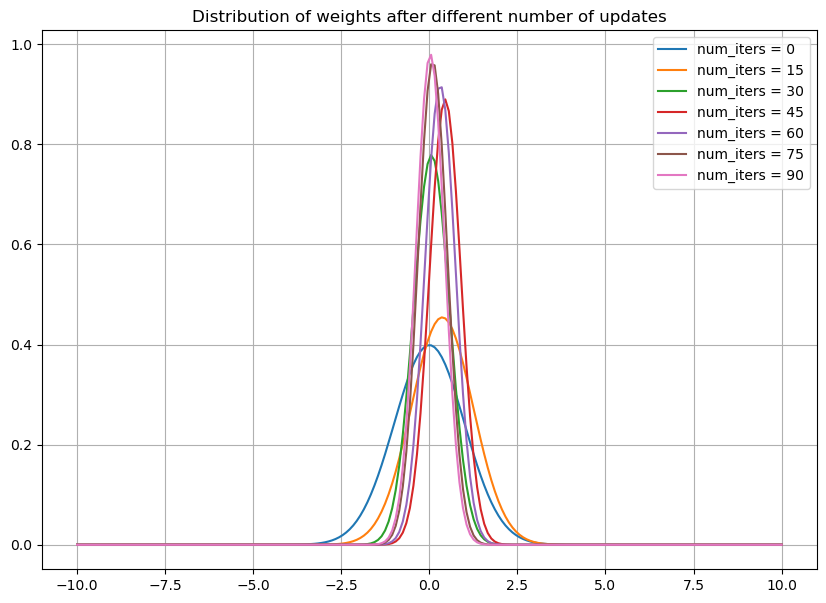

In [5]:
# beta = 1/(variance of epsilon).
beta = 100

# Function to perform the Sequential Updates.
def sequential_weight_update(x = x ,t = t, beta = beta, N = N , plot = False):
    
    # Initializing the mean and variance as per standard normal prior of weights.
    mean_weights = np.zeros(shape = (25,1))
    var_weights = np.identity(25)

    if(plot == True):
        plt.figure(figsize = (10 , 7))
        plt.title("Distribution of weights after different number of updates")
    for i in range(N):

        # Performing the Sequential Update.
        phi = create_feature_vector(x[i])
        var_weights_updated = np.linalg.inv(np.linalg.inv(var_weights) + beta*(phi@phi.T))
        mean_weights = var_weights_updated@(np.linalg.inv(var_weights)@mean_weights + t[i]*beta*phi)
        var_weights = var_weights_updated

        # Plot the Gaussian distribution of w_5 after every 10 iterations.
        if(i%15 == 0 and plot == True):
            x_vals = np.linspace(-10 , 10 , 200)
            pdf = (1/np.sqrt(2*np.pi*var_weights[5][5]))*np.exp(-(x_vals - mean_weights[5])**2/(2*var_weights[5][5]))
            plt.plot(x_vals , pdf , label = f'num_iters = {i}')
    if(plot == True):
        plt.legend()
        plt.grid()
        plt.show()
    return mean_weights , var_weights


mean_weights , var_weights = sequential_weight_update(plot = True)


### MAP Sampling and Curve Fits

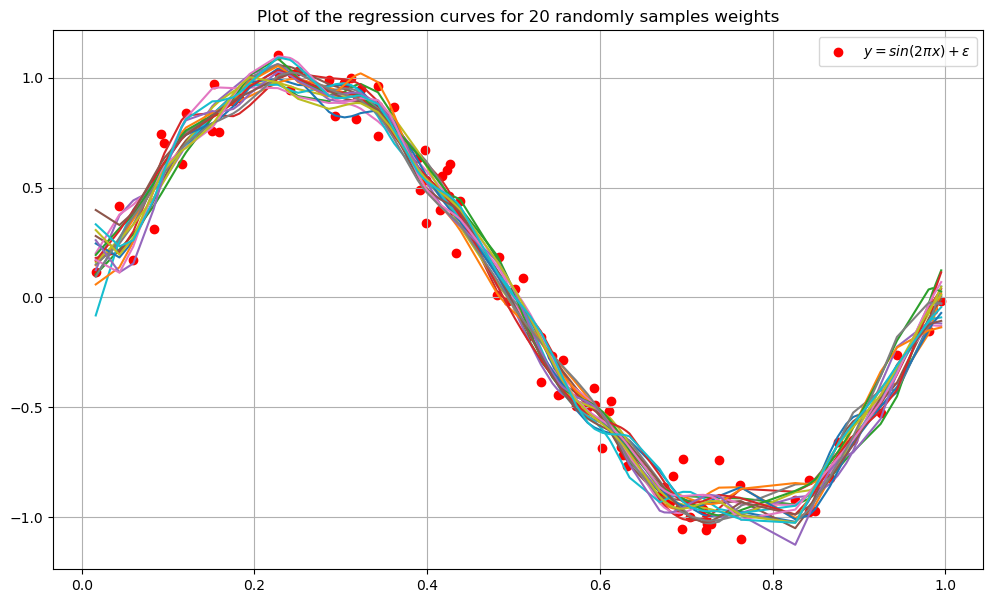

In [6]:
x_sorted = np.sort(x.flatten()) # Used while plotting the regression curve.

# Create the feature matrix
feature_matrix = np.array([create_feature_vector(a).T for a in x_sorted])

# Sampling 20 weight vectors from the distribution and plotting the regression curve.
plt.figure(figsize = (12 , 7))
plt.title("Plot of the regression curves for 20 randomly samples weights")
plt.scatter(x , t , c = 'r' , label = f'$y = sin(2\\pi x) + \\epsilon$')

avg_sample_weight = np.zeros_like(mean_weights) # Used for plotting the average curve.

for i in range(20):
    # Sampling from the multivariate distribution.
    sample_weight = np.random.multivariate_normal(mean_weights.flatten() , var_weights).reshape(-1,1)
    # Updating the average weight vector.
    avg_sample_weight += sample_weight
    # Plotting the regression curve.
    plt.plot(x_sorted , (feature_matrix@sample_weight).flatten())

avg_sample_weight /= 20
plt.legend()
plt.grid()
plt.show()


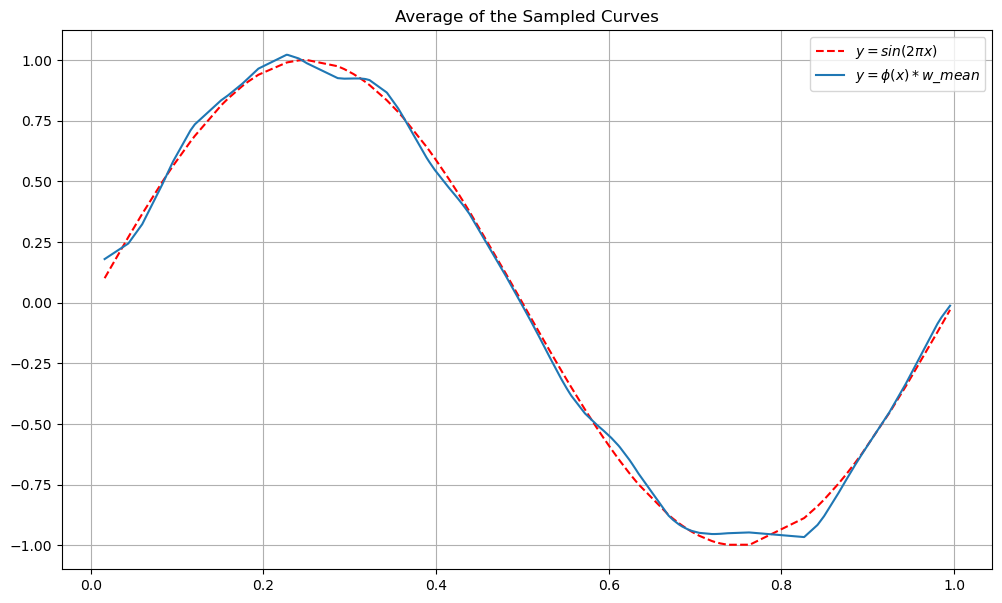

In [7]:
# Plotting the average of the sampled curves.
plt.figure(figsize = (12 , 7))
plt.title("Average of the Sampled Curves")
plt.plot(x_sorted , np.sin(2*np.pi*x_sorted) , 'r--' , label = f'$y = sin(2\\pi x)$')
plt.plot(x_sorted , (feature_matrix@avg_sample_weight).flatten() , label = f'$y = \\phi(x) * w\\_mean$')
plt.legend()
plt.grid()
plt.show()

### Posterior Predicitve Distribution
- $m(x_0) = \phi(x_0)^Tm_N$
- $s^2(x_0) = \frac{1}{\beta} + \phi(x_0)^TS_N\phi(x_0)$

In [8]:
np.random.seed(123) # Seeding

# Sampling 3 random test_samples and creating feature matrix.
num_samples = 3
test_samples = np.random.uniform(0 , 1 , size = (num_samples , 1))
phi = np.array([create_feature_vector(test_sample).T for test_sample in test_samples]).reshape(3,25)

# Computing the predictive mean and variances.
def predictive_mean_and_variance(mean_weights,var_weights , x):
    feature_matrix = create_feature_vector(x , mu , sigma).reshape(-1,1)
    predictive_mean = feature_matrix.T@mean_weights
    predictive_variance = 1/beta + feature_matrix.T @ var_weights @ feature_matrix
    return predictive_mean , predictive_variance


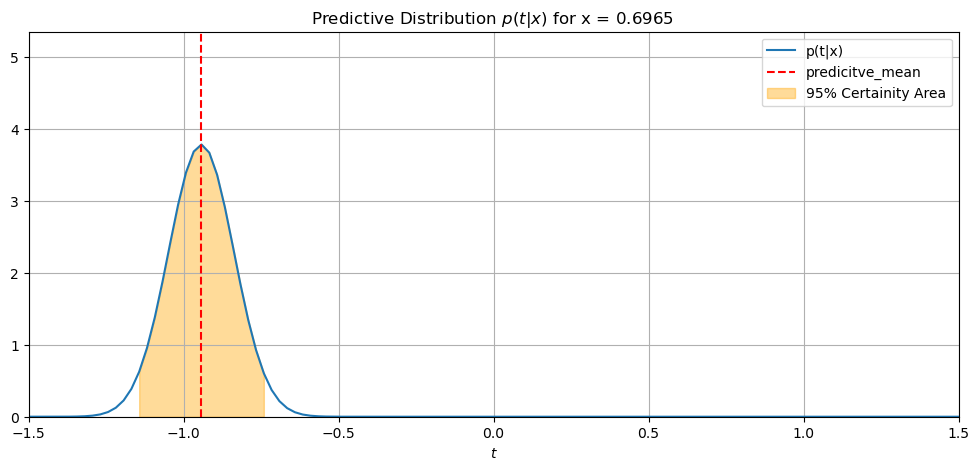

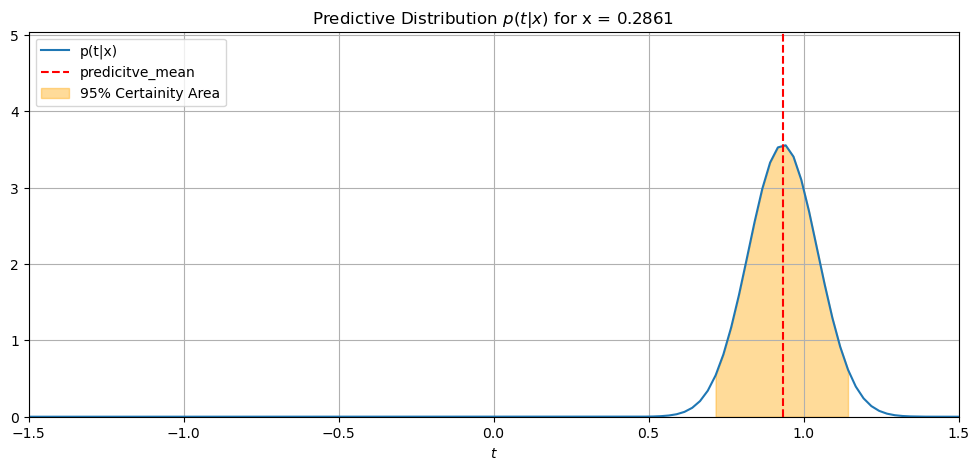

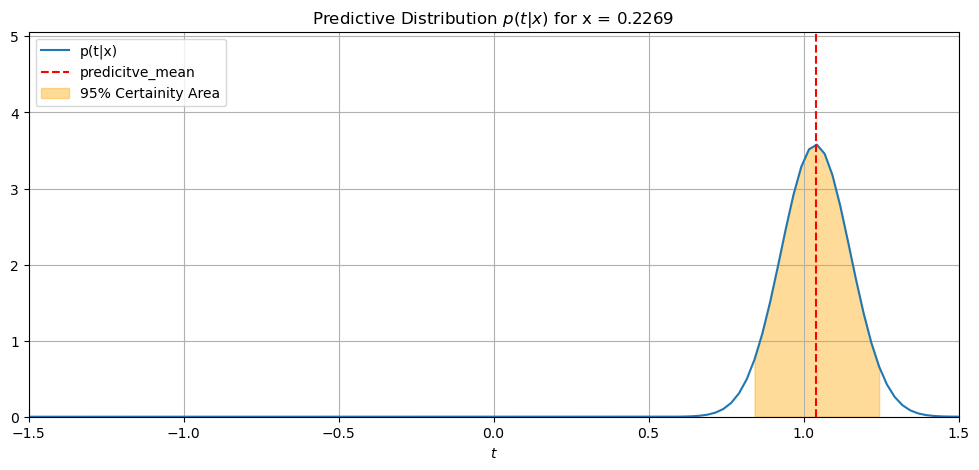

In [9]:
# Plotting the predictive conditinal distribution p(t|x) along with the 95% Certainity Area for the 
for test_sample in test_samples.flatten():

    # Predictive mean and variances for each test sample.
    predictive_mean , predictive_variance = predictive_mean_and_variance(mean_weights , var_weights , test_sample)

    # Generating the pdf using the mean and variances computed above.
    t_vals = np.linspace(-2.5,2.5,200)
    conditional_pdf = (1/np.sqrt(2*np.pi*predictive_variance))*np.exp(-(t_vals - predictive_mean)**2/(2*predictive_variance))

    # Plotting.

    plt.figure(figsize = (12,5))
    plt.title(f"Predictive Distribution $p(t|x)$ for x = {round(test_sample,4)} ")
    # Plot the pdf.
    plt.plot(t_vals.reshape(-1,1) , conditional_pdf.reshape(-1,1) , label = f'p(t|x)')
    # Overlay the predictive mean.
    plt.plot( predictive_mean * np.ones((10,1)), np.linspace(0,1/np.sqrt(np.pi*predictive_variance),10).reshape(10,1) , 'r--' , label = 'predicitve_mean')
    # Highlight the 95% Certainity Area.
    indices = [i for i in range(len(t_vals)) if predictive_mean[0][0] - 1.96 * np.sqrt(predictive_variance[0][0]) <= t_vals[i] <= predictive_mean[0][0] + 1.96 * np.sqrt(predictive_variance[0][0]) ]
    plt.fill_between(x = t_vals.flatten()[indices] , y1 = 0 , y2 = conditional_pdf.flatten()[indices] , alpha = 0.4 , color = 'orange' , label = f'95% Certainity Area')
    plt.legend()
    plt.grid()
    plt.xlim((-1.5,1.5))
    plt.ylim((0,1/np.sqrt(np.pi*predictive_variance)))
    plt.xlabel(f'$t$')
    plt.show()



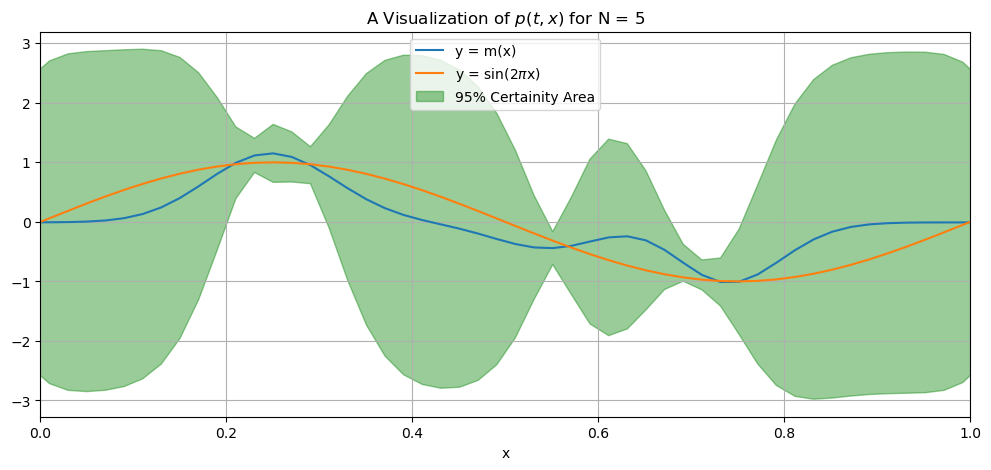

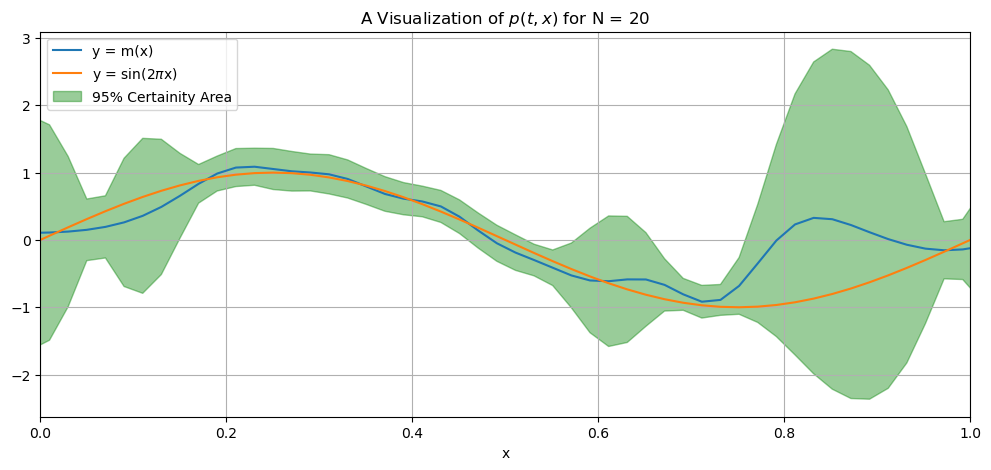

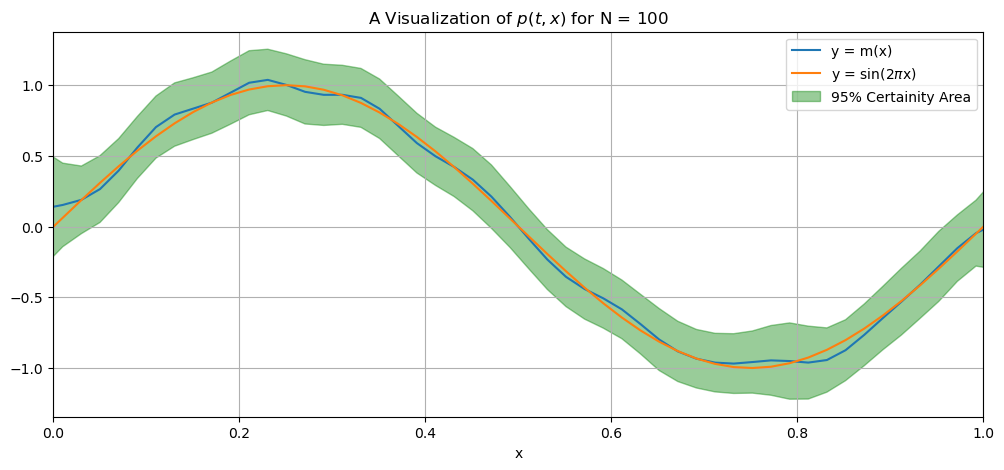

In [10]:
# Generating and plotting the joint predictive distribution p(t,x)
num_samples = 500
x_vals = np.linspace(-5,5,num_samples).reshape(-1,1)
N_vals = [5,20,100]

for N in N_vals:

    # Sampling first N elements from the dataset.
    x_new = x[0:N]
    t_new = t[0:N]

    # Finding the mean and variance of the weight distribution after sequential update rules.
    mean_weights , var_weights = sequential_weight_update(x_new , t_new , N = N)
    feature_matrix = np.array([create_feature_vector(a , mu  , sigma).T for a in x_vals]).reshape(num_samples,25)

    # Plotting the m(x) vs x graph with the 95% Certainity Area.
    predictive_means = (feature_matrix @ mean_weights).reshape(-1,1)
    predictive_variances = (1/beta + np.diagonal(feature_matrix @ var_weights @ feature_matrix.T)).reshape(-1,1)
    plt.figure(figsize = (12,5))
    plt.plot(x_vals , predictive_means , label = 'y = m(x)')
    plt.plot(x_vals , np.sin(2*np.pi*x_vals) , label = f'y = sin(2$\\pi$x)')
    plt.fill_between(x = x_vals.flatten() , y1 = (predictive_means + 1.96 * np.sqrt(predictive_variances)).flatten() , y2 = (predictive_means - 1.96 * np.sqrt(predictive_variances)).flatten() , color = 'green' , alpha = 0.4 , label = '95% Certainity Area')
    plt.legend()
    plt.title(f'A Visualization of $p(t,x)$ for N = {N}')
    plt.grid()
    plt.xlim((0,1))
    plt.xlabel('x')
    plt.show()


### Observations:
- As the number of training samples increase we see that the predicitve mean ($m(x)$ or the '$t$' value with highest probability for a given $x$ value) gets closer to the actual curve.
- Also the 95% Certainity Area gets narrower indicating that the true y-value is now probably closer to the mean.
- We can say that the variance of the distribution of y values decreases or the certainity in our prediction increases

# 2. Undrestanding Bias-Variance Tradeoff.

In [11]:
# Generating the Dataset

L = 100 # Number of Dataset
N = 25 # Samples per Dataset

# Seeding
np.random.seed(123)

# Generating Dataset
X = np.random.uniform(size = (L,N))
epsilon = np.random.normal(loc = 0 ,scale = 0.1 ,size = (L,N))
y = np.sin(2*np.pi*X) + epsilon

print("Shape of X is : " , X.shape , "\nShape of y is : " , y.shape) 

Shape of X is :  (100, 25) 
Shape of y is :  (100, 25)


### Closed form for optimal weights in Ridge Regression
-  $w^* = (\phi^T \phi + \lambda I) ^{-1}\phi^T y$

In [12]:
# Function that returns optimal weights for Ridge Regression.
def optimal_weight_for_ridge_regression(X , y , regularization_constant):
    # Create feature matrix
    feature_matrix = np.array([create_feature_vector(x).T for x in X]).reshape(25,25)
    # Calculate the weights using the above mentioned equation
    weights = np.linalg.inv(feature_matrix.T@feature_matrix + regularization_constant * np.identity(feature_matrix.shape[0])) @ feature_matrix.T @ y
    return weights


In [13]:
# Function to plot the regression curves using the ridge regression weights.
def plot_estimated_ridge_regression_curves(X , y , regularization_constant):

    plt.figure(figsize = (12,5))
    plt.title(f"Estimated Ridge Regression Curves for 100 different datasets for $\\lambda =${round(regularization_constant,4)} ")

    # Generate Sample Data and its feature matrix
    x_vals = np.linspace(0,1,200)
    feature_matrix = np.array([create_feature_vector(a).T for a in x_vals]).reshape(-1,N)


    weights_mean = np.zeros((N,1)) # Used to plot average regression curve

    # Plot the L = 100 Regression Curves
    for i in range(L):
        weights = optimal_weight_for_ridge_regression(X[i].reshape(-1,1) , y[i].reshape(-1,1) , regularization_constant )
        plt.plot(x_vals , feature_matrix @ weights)
        weights_mean += weights/L

    plt.xlim((0,1))
    plt.ylim((-1.5,1.5))
    plt.grid()
    plt.show()

    # Plot the actual Sine and the Average Regression Curves.
    y_vals = np.sin(2*np.pi*x_vals)
    plt.figure(figsize = (12,5))
    plt.title("Average of the above generated regression curves vs the original sinusoid.")
    plt.plot(x_vals , y_vals , label = f'$y =sin(2\\pi x)$ ')
    plt.plot(x_vals , feature_matrix @ weights_mean  , label = 'Average Regression Curve')
    plt.xlim((0,1))
    plt.ylim((-1.5,1.5))
    plt.legend()
    plt.grid()
    plt.show()
    


In [14]:
# Set the Regularization Constants
regularization_const_low = np.exp(-3)
regularization_const_mid = np.exp(0)
regularization_const_high = np.exp(3)


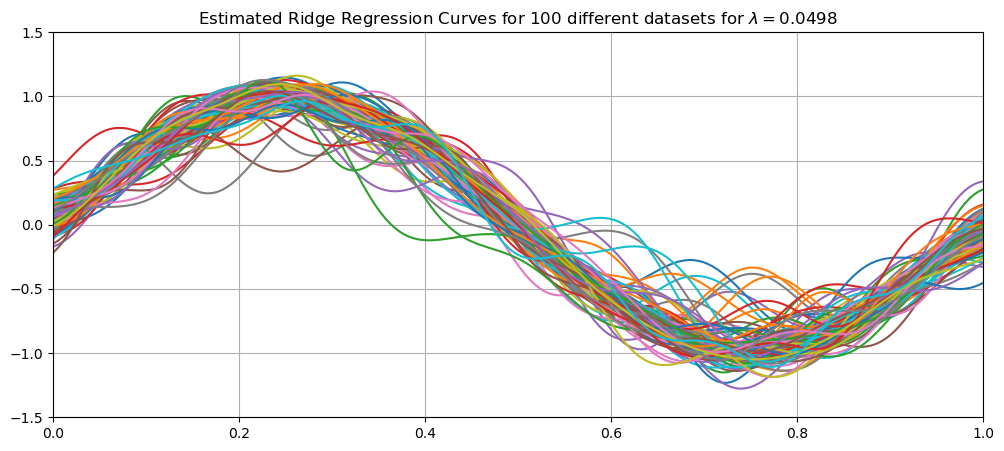

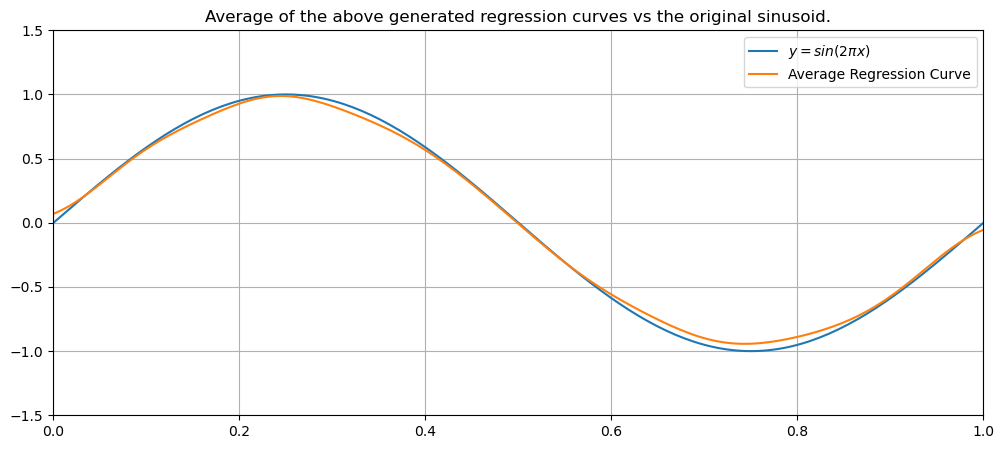

In [15]:
plot_estimated_ridge_regression_curves(X , y , regularization_constant = regularization_const_low)

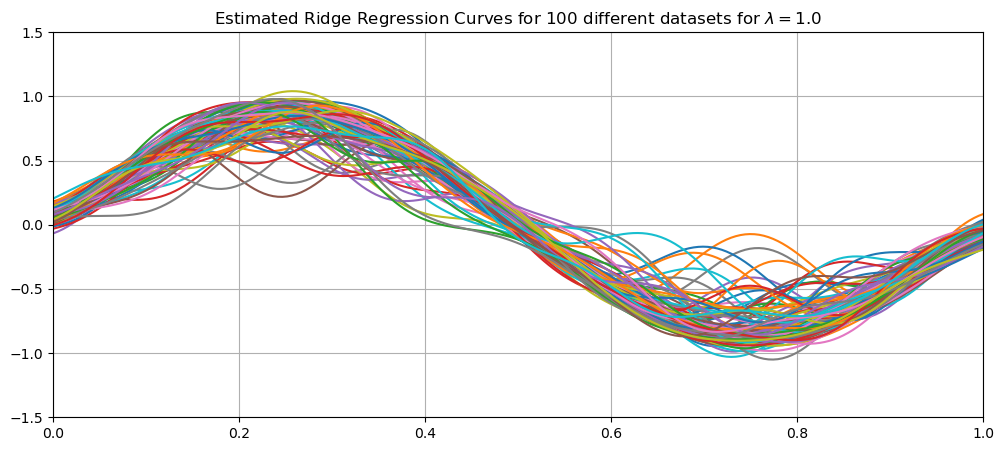

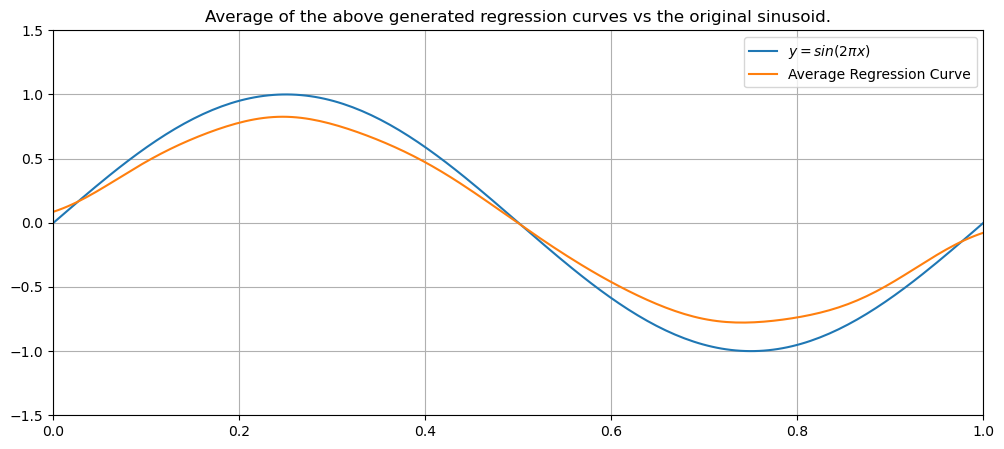

In [16]:
plot_estimated_ridge_regression_curves(X , y , regularization_constant = regularization_const_mid)

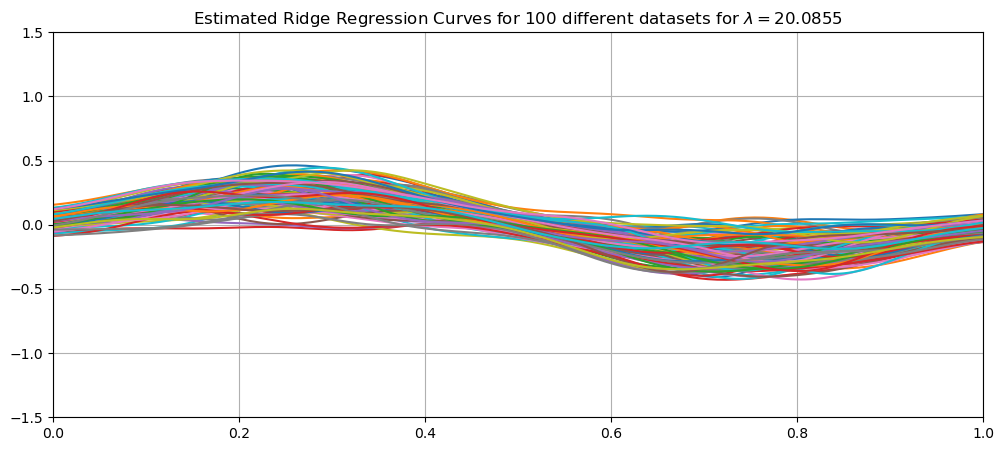

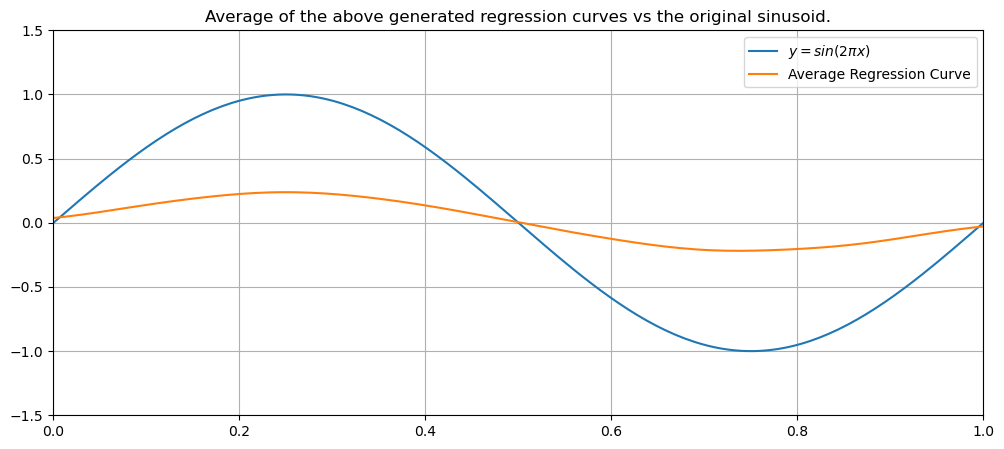

In [17]:
plot_estimated_ridge_regression_curves(X , y , regularization_constant = regularization_const_high)

### Observations
- As the value of $\lambda$ increases the variances between the curves generated from different datasets decreases meaning that dependence of the predicted regression curve on the dataset also decreases but since the weights are now heavily regularized all of them show a large(but nearly equal) deviation from the actual sine curve.
- In contrast , for smaller values of $\lambda$ it is seen that the average regression curve nearly matches the actual sine curve, but within the regression curves there is a very high variance meaning that for a given test sample, the prediction depends heavily on the dataset taken.
- The second curve is somewhat a more balanced one when compared in these aspects.

# 3. Understanding Generative Models and Discriminant Functions.

In [18]:
# A function to generate datasets (Each Class has its Class Conditional Distribution)
def generate_dataset(N_1 = 250 , N_2 = 250 , test = 0.2 ):
    # Parameters for generating Data 
    data_mean_1 = np.array([1,1])
    dat_var_1 = np.array([[2,0],[0 ,2]])
    data_mean_2 = np.array([-1,-1])
    data_var_2 = np.array([[0.75,0],[0,0.75]])

    # Generating Normal Distributions.
    X_1 = np.random.multivariate_normal(data_mean_1 , dat_var_1 , N_1)
    X_2 = np.random.multivariate_normal(data_mean_2, data_var_2 , N_2)

    # Stacking and Shuffling the data
    X = np.vstack((X_1,X_2))
    t = np.vstack((np.ones((N_1,1)) , np.zeros((N_2,1))))
    D = np.hstack((X,t))

    np.random.shuffle(D)

    X = D[:,:2] # Features
    t = D[:,2] # Classes

    # Test-train split.
    X_train = X[ : int(X.shape[0]*(1-test))]
    t_train = t[ : int(t.shape[0]*(1-test))]

    X_test = X[int(X.shape[0]*(1 - test)) : ]
    t_test = t[int(t.shape[0]*(1 - test)) : ]



    return X_1 , X_2 , X_train , t_train , X_test , t_test



In [19]:
# A function to add Gaussian noice to a Dataset
def add_noise_to_dataset(X_1 , X_2 , var , test = 0.2):

    # Add random Noice of given variance.
    X_1 += np.random.multivariate_normal(mean = [0,0] , cov = np.identity(2) , size = X_1.shape[0]) * var
    X_2 += np.random.multivariate_normal(mean = [0,0] , cov = np.identity(2) , size = X_2.shape[0]) * var

    # Stack the data , shuffle and extract features and labels.
    X = np.vstack((X_1,X_2))
    t = np.vstack((np.ones((len(X_1),1)) , np.zeros((len(X_2),1))))
    D = np.hstack((X,t))

    np.random.shuffle(D)
    X = D[:,:2]
    t = D[:,2]

    # Train - test split
    X_train = X[ : int(X.shape[0]*(1-test))]
    t_train = t[ : int(t.shape[0]*(1-test))]

    X_test = X[int(X.shape[0]*(1 - test)) : ]
    t_test = t[int(t.shape[0]*(1 - test)) : ]

    return X_1 , X_2 , X_train , t_train , X_test , t_test


In [20]:
# Generating Different Datasets.

X_1, X_2 , X_train , t_train ,X_test , t_test = generate_dataset()

X_1_imbalanced , X_2_imbalanced , X_train_imbalanced , t_train_imbalanced , X_test_imbalanced , t_test_imbalanced = generate_dataset(N_1 = 50 , N_2 = 450 )

low_noise = 0.5
high_noise = 3.0

X_1_low_noise , X_2_low_noise , X_train_low_noise , t_train_low_noise , X_test_low_noise , t_test_low_noise = add_noise_to_dataset(X_1.copy() , X_2.copy() ,var = low_noise)

X_1_high_noise , X_2_high_noise , X_train_high_noise , t_train_high_noise , X_test_high_noise , t_test_high_noise = add_noise_to_dataset(X_1.copy() , X_2.copy() , var = high_noise )


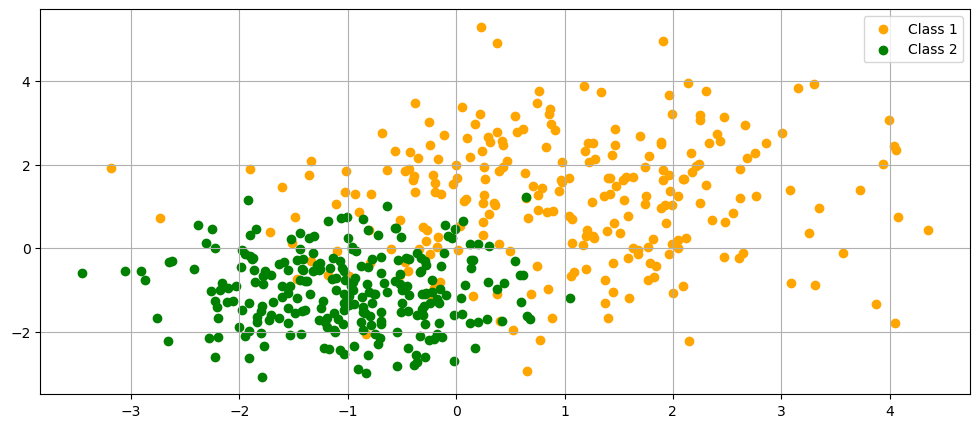

In [21]:

# Plotting the features classwise to make sure that the data is not trivially seperable.
plt.figure(figsize = (12,5))

plt.scatter(X_1[:,0],X_1[:,1] , c = 'orange' , label = 'Class 1')
plt.scatter(X_2[:,0],X_2[:,1] , c = 'green' , label = 'Class 2')

plt.grid()
plt.legend()
plt.show()




In [22]:
# Function to calculate train and test accuracies.
def accuracy(X , t , classifier , level):

    correctly_classified = 0
    # For each x if the predicted and true class are the same, the number of correctly_classified is incrimented. 
    for x,t in zip(X,t):
        x = x.reshape(-1,1)
        if((classifier(x) >= level and t == 1) or (classifier(x) < level and t == 0)):
            correctly_classified += 1
    
    # Accuracy is the numbers of currectly classified samples divided by the total number of samples.
    return correctly_classified / X.shape[0]

# Function to plot decision boundries.
def plot_decision_boundry(classifier , X_1 = X_1, X_2 = X_2 , level = 0.5 , scale = 5):

    # Generate a meshgrid.
    xx,yy = np.meshgrid(np.linspace(-scale,scale ,200) , np.linspace(-scale,scale,200)  )
    # Calculate classifier scores for each point in the meshgrid.
    Z = np.array([classifier(np.array([x,y]).reshape(-1,1)) for (x,y) in zip (xx.ravel() , yy.ravel())]).reshape(xx.shape)

    # Plot the decision boundries.
    plt.figure(figsize = (12,7))

    plt.scatter(X_1[:,0],X_1[:,1] , c = 'orange' , label = 'Class 1')
    plt.scatter(X_2[:,0],X_2[:,1] , c = 'green' , label = 'Class 2')
    plt.contour(xx , yy , Z , levels = [level] )

    plt.grid()
    plt.legend()
    plt.xlim(-scale,scale)
    plt.ylim(-scale,scale)

    plt.show()


## Gaussian Naive Bayes Classifier

- We take the assumption that for any data sample $x$ , the class conditional densities  are gaussian i.e.
$$p(x|C_k) = \mathcal{N}(m_k , S_k)$$
- We then estimate parameters as our Maximum Likelihood Solutions.

In [23]:
# Function to return a gaussian pdf, given mean and variance
def gaussian_pdf(mean , variance , x):
    return 1/(np.sqrt(2*np.pi*np.linalg.det(variance))) * np.exp(-(x - mean).T@np.linalg.inv(variance)@(x - mean)/2)


### Parameter Estimation and Implementing the Classifier

In [24]:
# A Function to estimate the MLE parameters for the GNB Classifier.
def estimate_GNB_parameters(X = X , t = t):

    # 1.Parameters for the assumed class conditional Gaussian distributions.
    mean_ML_1 = np.zeros((2,1))
    mean_ML_2 = np.zeros((2,1))
    Var_ML_1 = np.zeros((2,2))
    Var_ML_2 = np.zeros((2,2)) 

    # 2.Finding Number of Samples in Each class.
    N_1 = int(np.ones_like(t).T @ t)
    N_2 = int(np.ones_like(t).T @ (1 - t))

    # 3.MLE priors
    prior_class_1 = N_1 / (N_1 + N_2)
    prior_class_2 = N_2 / (N_1 + N_2)

    # 4.MLE class means
    mean_ML_1 = X.T @ t / N_1
    mean_ML_2 = X.T @ (1-t) / N_2

    # 5.MLE class Variances
    for x_i,t_i in zip(X,t):
        x_i = x_i.reshape(-1,1)
        Var_ML_1 += (x_i - mean_ML_1)@(x_i - mean_ML_1).T/N_1 * (t_i)
        Var_ML_2 += (x_i - mean_ML_2)@(x_i - mean_ML_2).T/N_2 * (1-t_i)

    return prior_class_1 , prior_class_2 , mean_ML_1 , mean_ML_2 , Var_ML_1 , Var_ML_2

prior_class_1 , prior_class_2 , mean_ML_1 , mean_ML_2 , Var_ML_1 , Var_ML_2 =  estimate_GNB_parameters(X = X_train , t = t_train)

def log_likelihood_GNB(x , t , prior_class_1 = prior_class_1, prior_class_2 = prior_class_2 , mean_ML_1 = mean_ML_1 , mean_ML_2 = mean_ML_2 , Var_ML_1 = Var_ML_1 , Var_ML_2 = Var_ML_2):
    return np.log((prior_class_1 * gaussian_pdf( mean_ML_1 , Var_ML_1 , x)[0][0])**t * (prior_class_2 * gaussian_pdf( mean_ML_2 , Var_ML_2 , x)[0][0]) ** (1 - t))


# Gives the classification Score.
def GNB_classifier(x , mean_1  , mean_2  , Var_1  , Var_2  , prior_1 , prior_2 ):
    
    class_1_prob = prior_1 * gaussian_pdf(mean_1 , Var_1 , x)[0][0]
    class_2_prob = prior_2 * gaussian_pdf(mean_2 , Var_2 , x)[0][0]

    return class_1_prob / (class_1_prob + class_2_prob) 



### Time Complexity Analysis:
- Part - 1 : (As labelled in the estimate parameters function) : declaring variables $O(1)$
- Part - 2 : Declaring an Array of size $n$ $O(n)$ and matmul $O(n)$ $\implies$ $O(n)$
- Part - 3 : Simple Calculations $O(1)$
- Part - 4 : Matrix Multiplication (2 $\times$ n) $\times$ (n $\times$ 1) $\implies$ $O(n)$
- Part - 5 : Each iteration takes $O(1)$ $\implies$ $O(n)$
- Overall time Complexity : $O(n)$


### Verification

In [25]:
# Consider a point belonging to the Class - 1
x = X_1[0].reshape(-1,1)

manual_log_likelihood = np.log(prior_class_1 * (1/(np.sqrt(2*np.pi*np.linalg.det(Var_ML_1))) * np.exp(-(x - mean_ML_1).T@np.linalg.inv(Var_ML_1)@(x - mean_ML_1)/2))[0][0])
code_log_likelihood = log_likelihood_GNB(x = x , t = 1)

print("The manually computed log-likelihood is : " , manual_log_likelihood)
print("The code computed log likelihood is : " , code_log_likelihood)


The manually computed log-likelihood is :  -3.389979985548692
The code computed log likelihood is :  -3.389979985548692


- We observe that both of them are equal

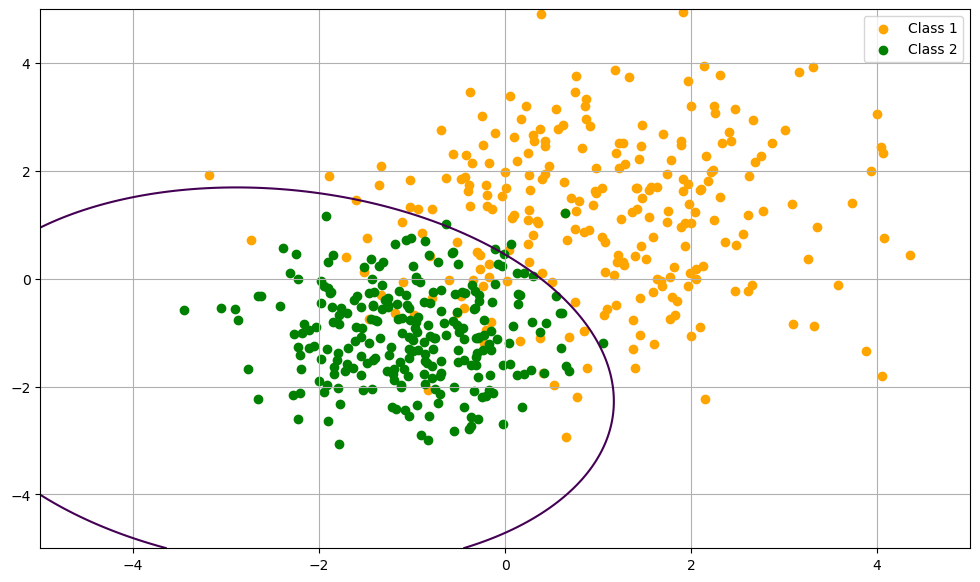

The training set accuracy for the GNB classifier is : 0.9025
The test set accuracy for the GNB classifier is : 0.94


In [26]:
# Wrapper Function to take the data, estimate parameters , plot the decision boundry and report accuracies.
def train_GNB_classifier(X_train = X_train , t_train = t_train , X_1 = X_1 , X_2 = X_2 , X_test = X_test , t_test = t_test , scale = 5 , plot = 1 ):

    prior_class_1 , prior_class_2 , mean_ML_1 , mean_ML_2 , Var_ML_1 , Var_ML_2 = estimate_GNB_parameters(X = X_train , t = t_train)
    classifier = partial(GNB_classifier , mean_1 = mean_ML_1 , mean_2 = mean_ML_2 , Var_1 = Var_ML_1 , Var_2 = Var_ML_2 , prior_1 = prior_class_1 , prior_2 = prior_class_2)

    train_accuracy =  accuracy(X_train , t_train , classifier , level = 0.5)
    test_accuracy = accuracy(X_test , t_test , classifier , level = 0.5)

    if(plot == 1):
        plot_decision_boundry(classifier , X_1 = X_1 , X_2 = X_2 , scale = scale)
        print("The training set accuracy for the GNB classifier is :" , train_accuracy)
        print("The test set accuracy for the GNB classifier is :" , test_accuracy)

    else:
        return train_accuracy , test_accuracy

# Implement the GNB classifier with the generated data
train_GNB_classifier(scale = 5)


### Effect of Class Imbalance

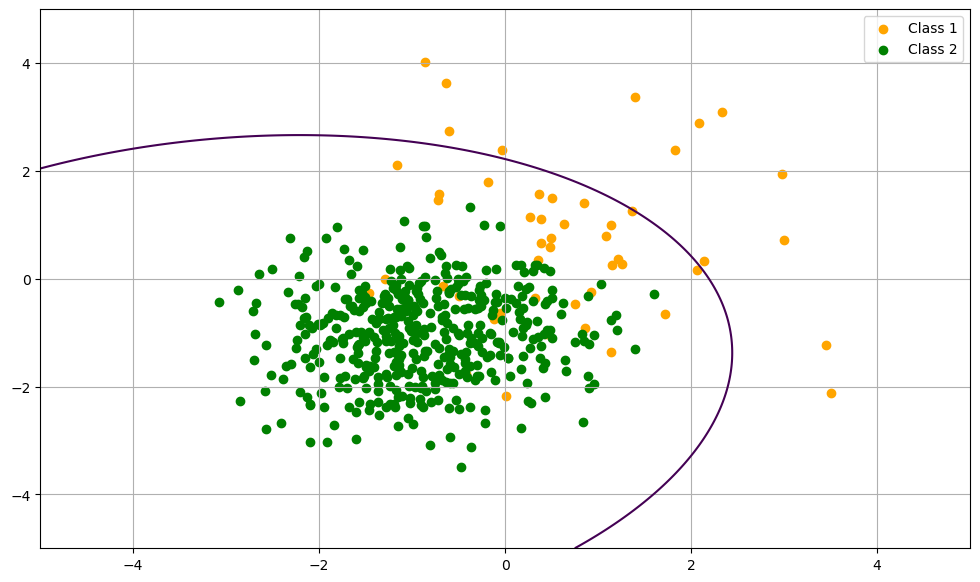

The training set accuracy for the GNB classifier is : 0.93
The test set accuracy for the GNB classifier is : 0.91


In [27]:
# Implement the GNB Classifier with Class Imbalanced Data.
train_GNB_classifier(X_train_imbalanced , t_train_imbalanced , X_1_imbalanced , X_2_imbalanced , X_test_imbalanced , t_test_imbalanced , scale = 5)


### Effect of Gaussian Noise.

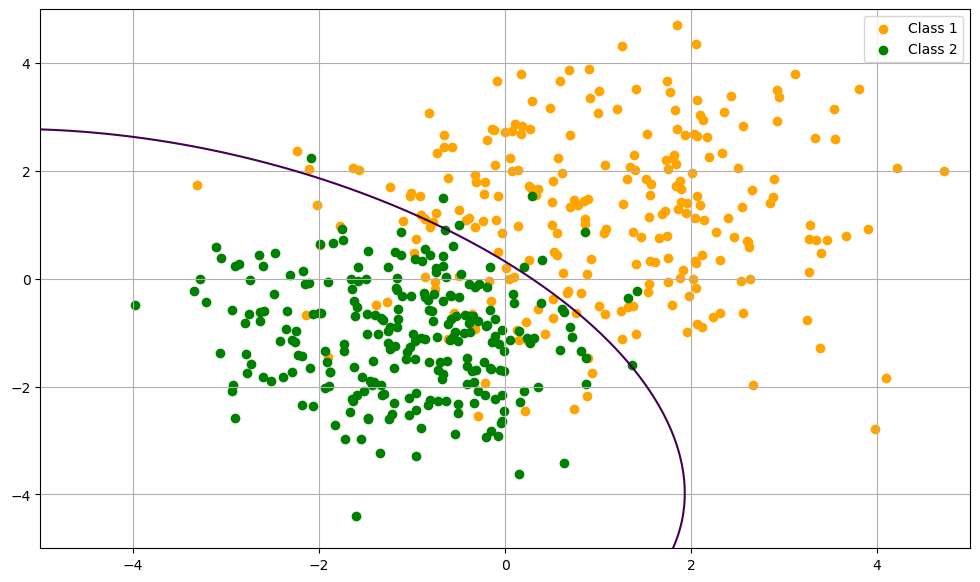

The training set accuracy for the GNB classifier is : 0.8975
The test set accuracy for the GNB classifier is : 0.89


In [28]:
# Implement the GNB Classifier with Noisy Data (low).
train_GNB_classifier(X_train_low_noise , t_train_low_noise , X_1_low_noise , X_2_low_noise , X_test_low_noise , t_test_low_noise)

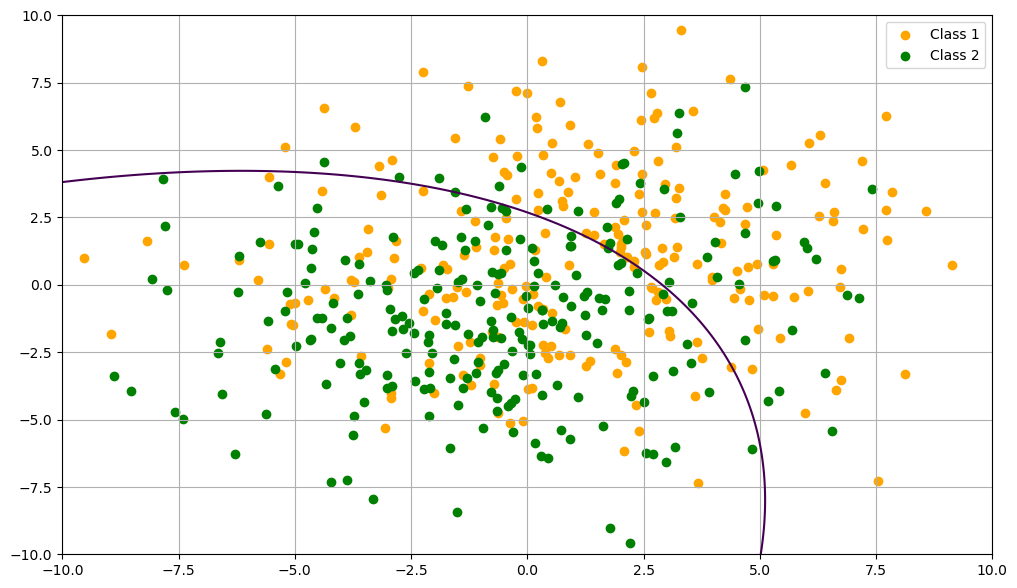

The training set accuracy for the GNB classifier is : 0.69
The test set accuracy for the GNB classifier is : 0.58


In [29]:
# Implement the GNB Classifier with Noisy Data (high).
train_GNB_classifier(X_train_high_noise , t_train_high_noise , X_1_high_noise , X_2_high_noise , X_test_high_noise , t_test_high_noise , scale = 10)

In [30]:
GNB_noise_accuracies = [] # Array to store accuracies after running 10 trials with different Noises 

for i in range(10):
    # Add Random Noise
    X_1_noise , X_2_noise ,X_train_noise , t_train_noise ,  X_test_noise , t_test_noise = add_noise_to_dataset(X_1.copy() , X_2.copy() , var = low_noise)
    # Calculate and store the accuracy
    GNB_noise_accuracies.append(train_GNB_classifier(X_train = X_train_noise , t_train = t_train_noise , X_1 = X_1_noise , X_2 = X_2_noise , X_test = X_test_noise , t_test = t_test_noise , plot = 0)[0])

for i in range(10):
    # Add Random Noise
    X_1_noise , X_2_noise ,X_train_noise , t_train_noise ,  X_test_noise , t_test_noise = add_noise_to_dataset(X_1.copy() , X_2.copy() , var = high_noise)
    # Calculate and store the accuracy
    GNB_noise_accuracies.append(train_GNB_classifier(X_train = X_train_noise , t_train = t_train_noise , X_1 = X_1_noise , X_2 = X_2_noise , X_test = X_test_noise , t_test = t_test_noise , plot = 0)[0])

## Linear Discriminant Analysis.
- Here we use Fischer's Linear Discriminant Method
- $w \propto S_w^{-1}(m_2 - m_1)$

- Where $m_1$ is the mean of class 1 and $m_2$ is the mean of class 2 and $m$ is the combined mean.
- $S_w = \sum_{n \in C_1} (x_n - m_1)(x_n - m_1)^T/2 + \sum_{n \in C_2} (x_n - m_2)(x_n - m_2)^T/2$ is the within class covariance Matrix.
- Classification Rule:
    If $w^Tx > w^Tm$ then Class 1 else Class 2

In [31]:
# Estimate Parameters using Fischers Linear Discriminant Method.
def estimate_LDA_parameters(X = X, t = t ):

    # 1. Number of Samples in each class
    N_1 = np.ones((t.shape[0],1)).T @ t
    N_2 = np.ones((X.shape[0],1)).T @(1 - t)

    # 2. Mean of features in each class
    m_1 = (X.T @ t / N_1).reshape(-1,1)
    m_2 = (X.T @ (1 - t)/N_2).reshape(-1,1)

    # 3. Within Class Covariance Matrix
    S_w = np.zeros((2,2))
    for x_n,t_n in zip(X,t):
        x_n = x_n.reshape(-1,1)
        S_w += t_n * (x_n - m_1) @ (x_n - m_1).T / N_1 + (1 - t_n) * (x_n - m_2) @ (x_n - m_2).T / N_2

    # 4. Mean of the dataset.
    m = N_1 / N * m_1 + N_2 / N * m_2

    # 5. Direction along which the data is projected i.e. the weight.
    w = np.linalg.inv(S_w) @ (m_1 - m_2)

    return w/np.linalg.norm(w) , m

w , m = estimate_LDA_parameters(X_train , t_train)

# Classifier to return Scores of data Samples.
def LDA_classifier(x , w , m ):
    return (w.T @ (x - m))[0][0]

 




### Time Complexity Analysis:
- Part - 1 : (As labelled in the estimate parameters function) : Declaring an Array of size $n$  $O(n)$ and matmul $O(n)$ $\implies$ $O(n)$
- Part - 2 : matmul $O(n)$
- Part - 3 : In each iteration $O(1)$ $\implies$ $O(n)$
- Part - 4 : Simple Calculation $O(1)$
- Part - 5 : Simple Calculation $O(1)$ (Does not involve any N-d array )
- Overall time Complexity : $O(n)$

### Verification
- We calculate the least squares solution and verify the obtained weights with it.
- $w^* = (X^TX)^{-1}X^Tt$

In [32]:
# Finding the normalized least squares weights
w_lsq = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ t_train  
w_lsq = w_lsq / np.linalg.norm(w_lsq)

# Comparing.
print("The weight vector obtained from Fischers LDA is : ",w.flatten() , "\nThe weight vector obtained from Least Squares is : " , w_lsq)

The weight vector obtained from Fischers LDA is :  [0.7790636 0.6269449] 
The weight vector obtained from Least Squares is :  [0.69386115 0.72010881]


- We can see that the weights obtained are quite similar

### Implementing the classifier

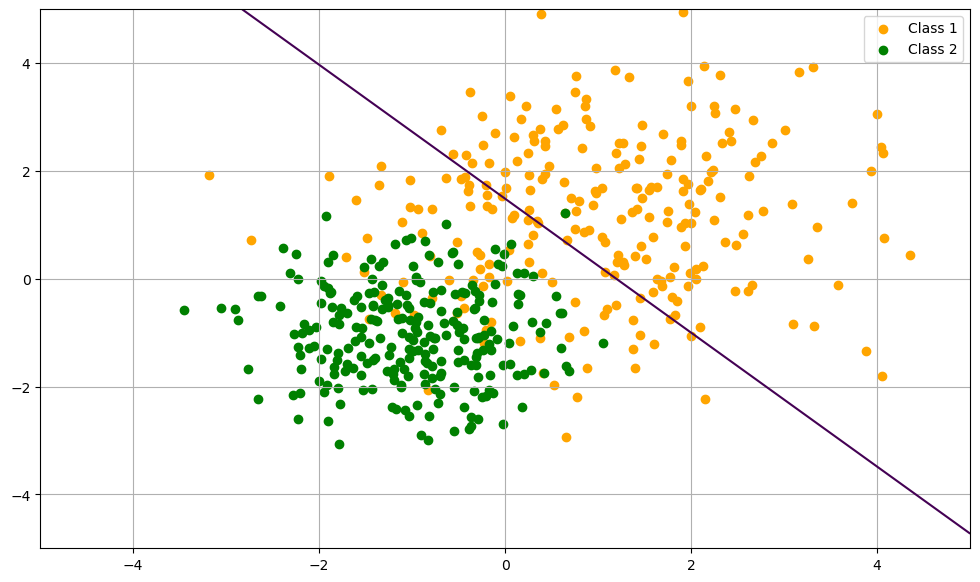

The training set accuracy for the GNB classifier is : 0.8275
The test set accuracy for the GNB classifier is : 0.87


In [33]:
# Wrapper Function to take the data, estimate parameters , plot the decision boundry and report accuracies.
def train_LDA_classifier(X_train = X_train , t_train = t_train , X_1 = X_1 , X_2 = X_2 , X_test = X_test , t_test = t_test , scale = 5 , plot = 1):
    w , m = estimate_LDA_parameters(X = X_train , t = t_train)
    classifier = partial(LDA_classifier , w = w , m = m)

    train_accuracy =  accuracy(X_train , t_train , classifier , level = 0)
    test_accuracy = accuracy(X_test , t_test , classifier , level = 0)
    if(plot == 1):
        plot_decision_boundry(classifier , X_1 = X_1 , X_2 = X_2 , scale = scale , level = 0)
        print("The training set accuracy for the GNB classifier is :" , train_accuracy )
        print("The test set accuracy for the GNB classifier is :" , test_accuracy )
    else:
        return train_accuracy , test_accuracy

# Implement the LDA classifier with the generated data    
train_LDA_classifier()

### Effect of Class Imbalance

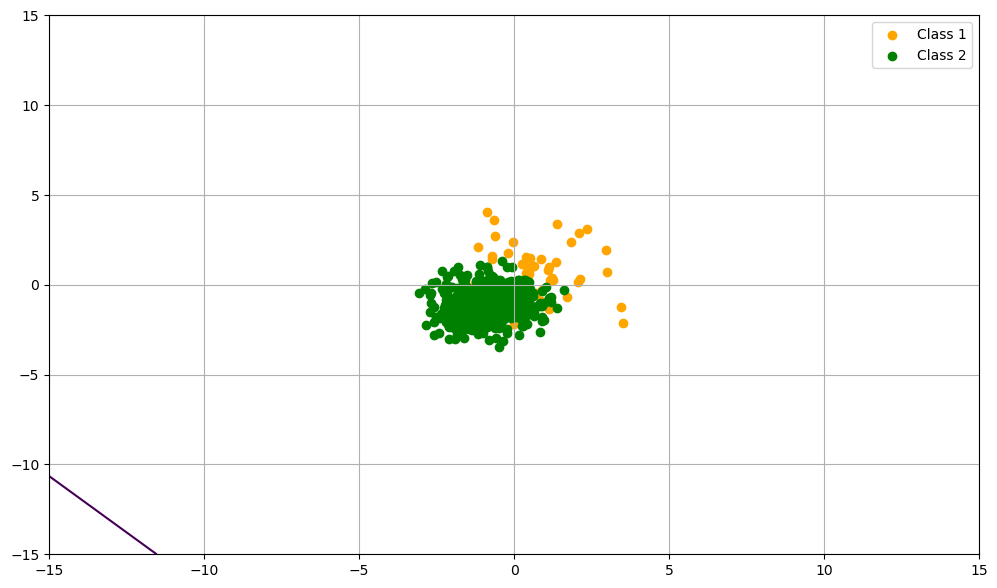

The training set accuracy for the GNB classifier is : 0.095
The test set accuracy for the GNB classifier is : 0.12


In [34]:
# Implement the LDA Classifier with Class Imbalanced Data.
train_LDA_classifier(X_train_imbalanced , t_train_imbalanced , X_1_imbalanced , X_2_imbalanced , X_test_imbalanced , t_test_imbalanced , scale = 15)


### Effect of Gaussian Noise.

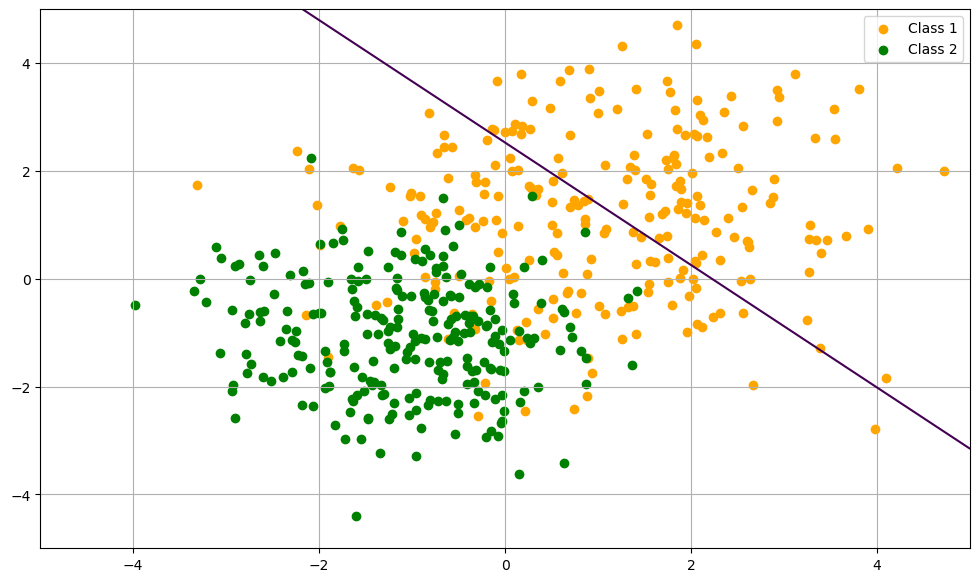

The training set accuracy for the GNB classifier is : 0.7325
The test set accuracy for the GNB classifier is : 0.73


In [35]:
# Implement the LDA Classifier with Noisy Data (low).
train_LDA_classifier(X_train_low_noise , t_train_low_noise , X_1_low_noise , X_2_low_noise , X_test_low_noise , t_test_low_noise , scale = 5)

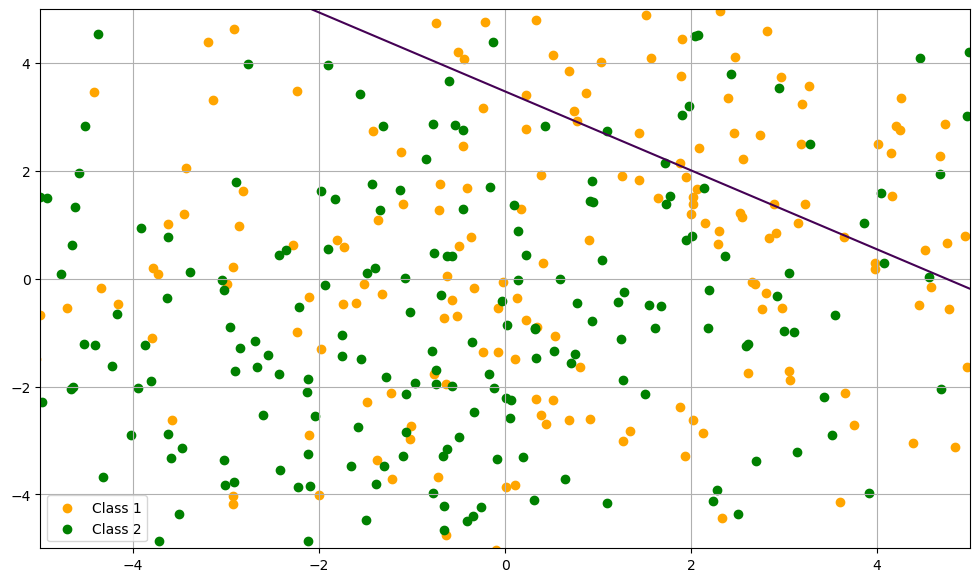

The training set accuracy for the GNB classifier is : 0.65
The test set accuracy for the GNB classifier is : 0.53


In [36]:
# Implement the LDA Classifier with Noisy Data (high).
train_LDA_classifier(X_train_high_noise , t_train_high_noise , X_1_high_noise , X_2_high_noise , X_test_high_noise , t_test_high_noise , scale = 5)

In [37]:
LDA_noise_accuracies = [] # Array to store accuracies after running 10 trials with different Noises 

for i in range(10):
    # Add Random Noise
    X_1_noise , X_2_noise ,X_train_noise , t_train_noise ,  X_test_noise , t_test_noise = add_noise_to_dataset(X_1.copy() , X_2.copy() , var = low_noise)
    # Calculate and store the accuaracy
    LDA_noise_accuracies.append(train_LDA_classifier(X_train = X_train_noise , t_train = t_train_noise , X_1 = X_1_noise , X_2 = X_2_noise , X_test = X_test_noise , t_test = t_test_noise , plot = 0)[0])

for i in range(10):
    # Add Random Noise
    X_1_noise , X_2_noise ,X_train_noise , t_train_noise ,  X_test_noise , t_test_noise = add_noise_to_dataset(X_1.copy() , X_2.copy() , var = high_noise)
    # Calculate and store the accuaracy
    LDA_noise_accuracies.append(train_LDA_classifier(X_train = X_train_noise , t_train = t_train_noise , X_1 = X_1_noise , X_2 = X_2_noise , X_test = X_test_noise , t_test = t_test_noise , plot = 0)[0])


## L2 Regularization with LDA
- Here $S_w \rightarrow S_w + \lambda I$
$\implies w \propto ((1-\lambda) S_w + \lambda I)^{-1}(m_2 - m_1)$ 

In [38]:
# Set regularization constant
regularization_const = 0.75

def estimate_L2_LDA_parameters(X = X_train , t = t_train , regularization_const = regularization_const):
    # 1.Number of Samples in each class
    N_1 = np.ones((t.shape[0],1)).T @ t
    N_2 = np.ones((X.shape[0],1)).T @(1 - t)

    # 2.Means of Each class.
    m_1 = (X.T @ t / N_1).reshape(-1,1)
    m_2 = (X.T @ (1 - t)/N_2).reshape(-1,1)

    # 3.Within Class covariance.
    S_w = np.zeros((2,2))

    for x_n,t_n in zip(X,t):
        x_n = x_n.reshape(-1,1)
        S_w += t_n * (x_n - m_1) @ (x_n - m_1).T / N_1 + (1 - t_n) * (x_n - m_2) @ (x_n - m_2).T / N_2

    # 4.Total mean
    m = N_1 / N * m_1 + N_2 / N * m_2

    # 5.Direction along which the data is projected i.e. the weight.
    w = np.linalg.inv((1 - regularization_const) * S_w + regularization_const * np.identity(2)) @ (m_1 - m_2)

    return w/np.linalg.norm(w) , m 

w , m = estimate_L2_LDA_parameters(X_train , t_train)
# Gives the score for a given data sample.
def L2_LDA_classifier(x , w , m ):
    return (w.T @ (x - m))[0][0]




### Time Complexity Analysis:
- Part - 1 : (As labelled in the estimate parameters function) : Declaring an Array of size $n$  $O(n)$ and matmul $O(n)$ $\implies$ $O(n)$
- Part - 2 : matmul $O(n)$
- Part - 3 : In each iteration $O(1)$ $\implies$ $O(n)$
- Part - 4 : Simple Calculation $O(1)$
- Part - 5 : Simple Calculation $O(1)$ (Does not involve any N-d array )
- Overall time Complexity : $O(n)$

### Verification
- We calculate the least squares solution and verify the obtained weights with it.
- $w^* = (X^TX)^{-1}X^Tt$

In [39]:
# Finding the normalized least squares weights
w_lsq = np.linalg.inv(X_train.T @ X_train + regularization_const * np.identity(2)) @ X_train.T @ t_train  
w_lsq = w_lsq / np.linalg.norm(w_lsq)

# Comparing.
print("The weight vector obtained from Fischers LDA with regularization is : ",w.flatten() , "\nThe weight vector obtained from Least Squares with Regularization is : " , w_lsq)

The weight vector obtained from Fischers LDA with regularization is :  [0.72691836 0.68672389] 
The weight vector obtained from Least Squares with Regularization is :  [0.69379122 0.72017618]


- As we can see the weights are quite similar

### Implementing the classifier

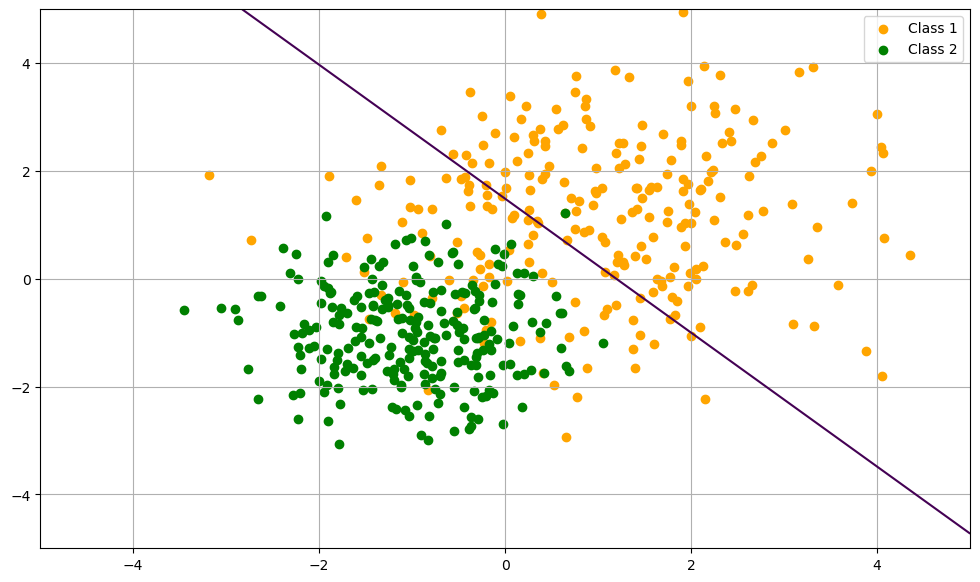

The training set accuracy for the GNB classifier is : 0.8275
The test set accuracy for the GNB classifier is : 0.87


In [40]:
# Wrapper Function to take the data, estimate parameters , plot the decision boundry and report accuracies.
def train_L2_LDA_classifier(X_train = X_train , t_train = t_train , X_1 = X_1 , X_2 = X_2 , X_test = X_test , t_test = t_test , scale = 5 , plot = 1):
    w , m = estimate_L2_LDA_parameters(X = X_train , t = t_train)
    classifier = partial(L2_LDA_classifier , w = w , m = m)

    train_accuracy =  accuracy(X_train , t_train , classifier , level = 0)
    test_accuracy = accuracy(X_test , t_test , classifier , level = 0)
    if(plot == 1):
        plot_decision_boundry(classifier , X_1 = X_1 , X_2 = X_2 , scale = scale , level = 0)
        print("The training set accuracy for the GNB classifier is :" , train_accuracy )
        print("The test set accuracy for the GNB classifier is :" , test_accuracy )
    else:
        return train_accuracy , test_accuracy
    
# Implement the LDA classifier with L2 regularization with the generated data  
train_LDA_classifier()

### Effect of Class Imbalance

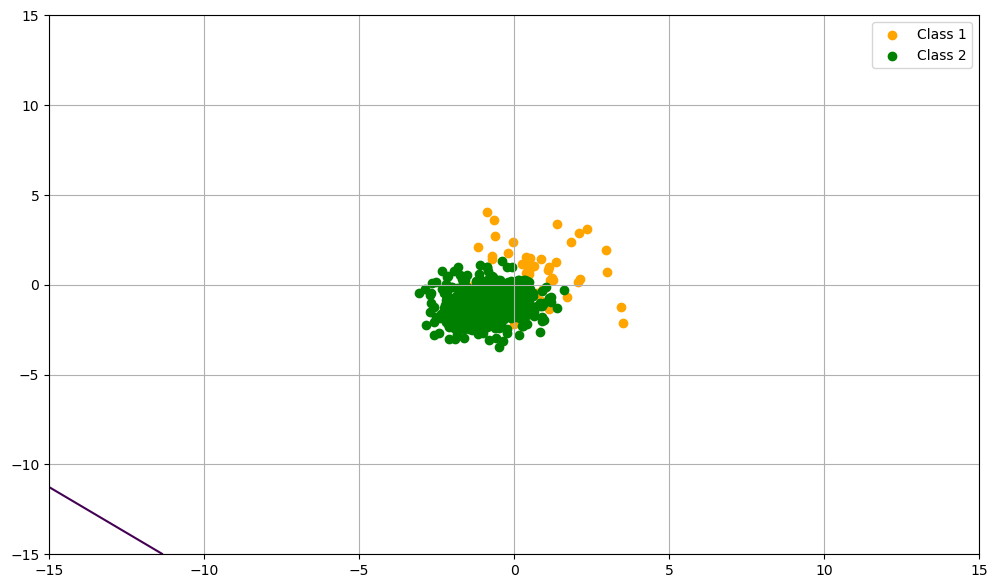

The training set accuracy for the GNB classifier is : 0.095
The test set accuracy for the GNB classifier is : 0.12


In [41]:
# Implement the LDA with L2 Classifier with Class Imbalanced Data.
train_L2_LDA_classifier(X_train_imbalanced , t_train_imbalanced , X_1_imbalanced , X_2_imbalanced , X_test_imbalanced , t_test_imbalanced , scale = 15)


### Effect of Gaussian Noice

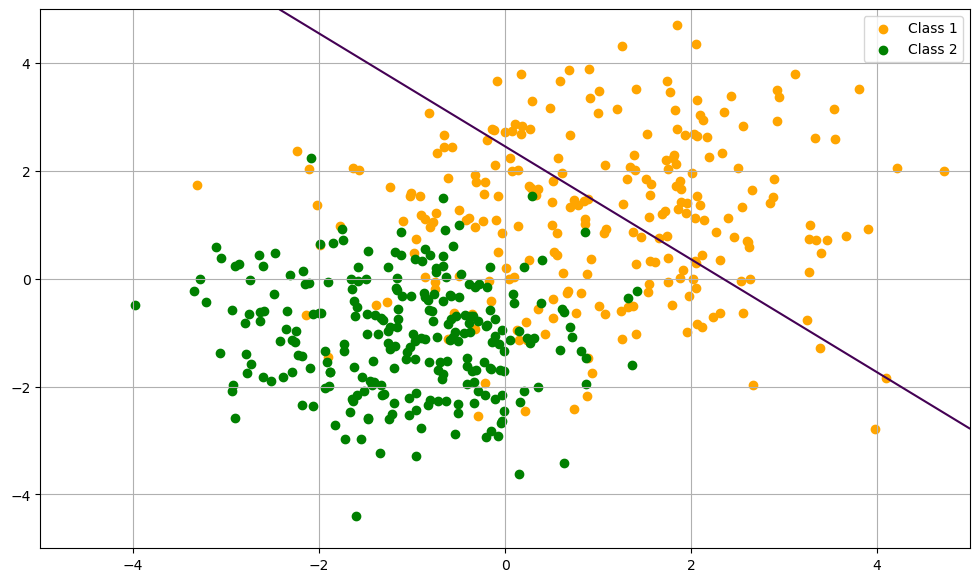

The training set accuracy for the GNB classifier is : 0.7275
The test set accuracy for the GNB classifier is : 0.72


In [42]:
# Implement the LDA with L2 Classifier with Noisy Data (low).
train_L2_LDA_classifier(X_train_low_noise , t_train_low_noise , X_1_low_noise , X_2_low_noise , X_test_low_noise , t_test_low_noise , scale = 5)

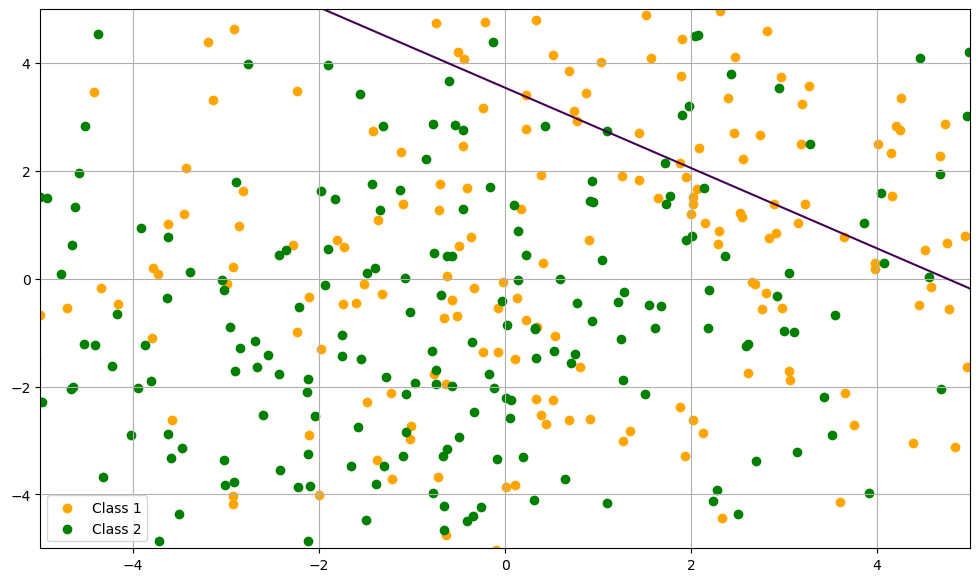

The training set accuracy for the GNB classifier is : 0.645
The test set accuracy for the GNB classifier is : 0.53


In [43]:
# Implement the LDA with L2 Classifier with Noisy Data (high).
train_L2_LDA_classifier(X_train_high_noise , t_train_high_noise , X_1_high_noise , X_2_high_noise , X_test_high_noise , t_test_high_noise , scale = 5)

In [44]:
L2_LDA_noise_accuracies = [] # Array to store accuracies after running 10 trials with different Noises # Add Random Noise

for i in range(10):
    # Add Random Noise
    X_1_noise , X_2_noise ,X_train_noise , t_train_noise ,  X_test_noise , t_test_noise = add_noise_to_dataset(X_1.copy() , X_2.copy() , var = low_noise)
    # Calculate and Store the accuracy
    L2_LDA_noise_accuracies.append(train_L2_LDA_classifier(X_train = X_train_noise , t_train = t_train_noise , X_1 = X_1_noise , X_2 = X_2_noise , X_test = X_test_noise , t_test = t_test_noise , plot = 0)[0])

for i in range(10):
    # Add Random Noise
    X_1_noise , X_2_noise ,X_train_noise , t_train_noise ,  X_test_noise , t_test_noise = add_noise_to_dataset(X_1.copy() , X_2.copy() , var = high_noise)
    # Calculate and Store the accuracy
    L2_LDA_noise_accuracies.append(train_L2_LDA_classifier(X_train = X_train_noise , t_train = t_train_noise , X_1 = X_1_noise , X_2 = X_2_noise , X_test = X_test_noise , t_test = t_test_noise , plot = 0)[0])


## Bernoulli Naive Bayes

- Here we project the features into discrete binary feature space and classify them.
- let $x = [x_1 , x_2]$
- The Naive assumption is to take that $x_1|C_k$ is independent of $x_2|C_k$ and both of them are conditionally Bernoulli RVs.
- Parameters Used : 
- $p(x_1 = 1|C_1) = p_{11} $
- $p(x_2 = 1|C_1) = p_{21} $
- $p(x_1 = 1|C_2) = p_{12} $
- $p(x_2 = 1|C_2) = p_{22} $
- $p(C_1) \rightarrow $ prior_class_1
- $p(C_2) \rightarrow $ prior_class_2 
- Parameters are estimated using the MLE solutions.

In [45]:
# Function to binarize the data (each feature is assigned 1 if it is greater than the mean of the values in the dataset).
def binarize( x = np.zeros((2,1)), X = X_train , t = t_train , Dataset = 1):
    # Calculate the mean.
    mean = np.mean(X , axis = 0)
    binary = []

    # Binarize
    if(Dataset == 1):
        for x in X:
            binarized = [0,0]
            if(x[0] > mean[0]):
                binarized[0] = 1
            if(x[1] > mean[1]):
                binarized[1] = 1

            binary.append(binarized)
    else:
        if(x[0] > mean[0]):
            binary.append(1)
        else:
            binary.append(0)

        if(x[1] > mean[1]):
            binary.append(1)
        else:
            binary.append(0)

    
        
    return np.array(binary)




# Estimate the MLE parameters.
def estimate_BNB_parameters(X = binarize(X = X_train) , t = t_train):
    # 1. Number of samples in each class
    N_1 = (np.ones_like(t).T @ t)
    N_2 = (np.ones_like(t).T @ (1 - t))

    # 2. Class Priors
    prior_class_1 = N_1 / (N_1 + N_2)
    prior_class_2 = N_2 / (N_1 + N_2)

    # 3. Bernoulli parameters
    means_1 = X.T @ t / N_1
    p11 = means_1[0]
    p21 = means_1[1]
    means_2 = X.T @ (1 - t) / N_2
    p12 = means_2[0]
    p22 = means_2[1]

    return prior_class_1 , prior_class_2 , p11 , p21 , p12 , p22

prior_class_1 , prior_class_2 , p11 , p21 , p12 , p22 = estimate_BNB_parameters()


def BNB_classifier(x , prior_class_1  , prior_class_2  , p11  , p21  , p12  , p22 ):
    # Binarize x
    x = x.reshape(2,1)
    x = binarize(x , Dataset = 0 )
    
    # Calculate P(x | C_k) * p(C_k)
    prob_class_1 = prior_class_1 * (p11 ** x[0]) * ((1-p11)**(1 - x[0])) * ((p21 ** x[1]) * ((1-p21)**(1 - x[1])))
    prob_class_2 = prior_class_2 * (p12 ** x[0]) * ((1-p12)**(1 - x[0])) * ((p22 ** x[1]) * ((1-p22)**(1 - x[1])))

    # Return the Posterior Score P(C_k | x)
    return prob_class_1 / (prob_class_1 + prob_class_2)




    
    


### Time Complexity Analysis:
- Part - 1 : (As labelled in the estimate parameters function) : Declaring an Array of size $n$  $O(n)$ and matmul $O(n)$ $\implies$ $O(n)$
- Part - 2 : Simple Calculation $O(1)$
- Part - 3 : matmul for mean $O(n)$

- Overall time Complexity : $O(n)$

### Verification

In [46]:
x = X_1[0].reshape(-1,1)
binarize(x , Dataset = 0)
print("x = " , x.flatten())

x =  [0.0991079  2.62678998]


- The manual probability is going to be $\frac{p(x|C_1)p(C_1)}{p(x|C_1)p(C_1) + p(x|C_2)p(C_2)}$

In [47]:
manual_class_probability = (prior_class_1 * (p11 * p21))/(prior_class_1 * p11 * p21 + prior_class_2 * p12 * p22)
code_class_probability = BNB_classifier(x = x , prior_class_1 = prior_class_1 , prior_class_2 = prior_class_2 , p11 = p11 , p21 = p21 , p12 = p12 , p22 = p22)

print("The Manually computed class probability is : ", manual_class_probability)
print("The code computed class probability is : ", code_class_probability)

The Manually computed class probability is :  0.9776277150524023
The code computed class probability is :  0.9776277150524023


- As we can see the manually computed one and the probability computed in the function match

### Implementing the classifier

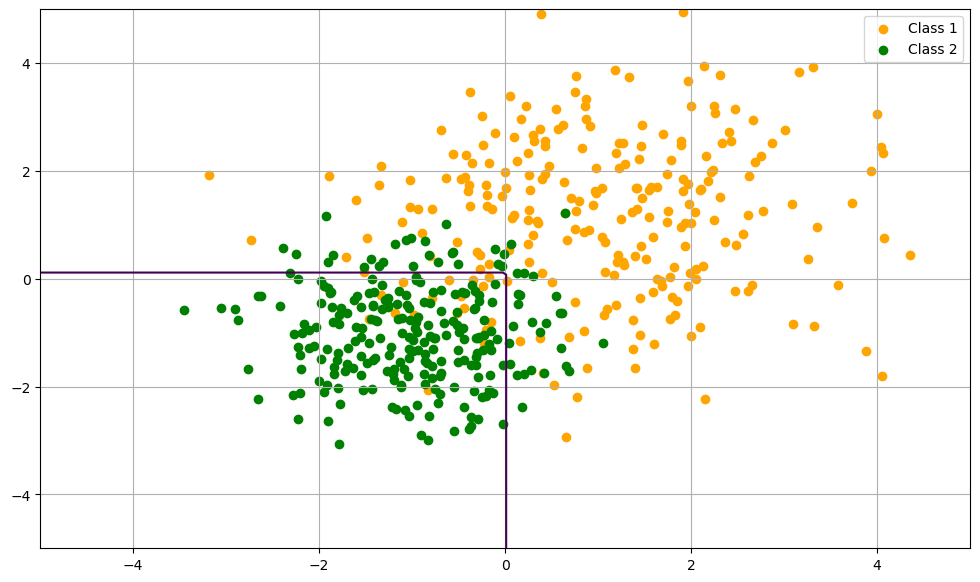

The training set accuracy for the GNB classifier is : 0.855
The test set accuracy for the GNB classifier is : 0.9


In [48]:
# Wrapper Function to take the data, estimate parameters , plot the decision boundry and report accuracies.
def train_BNB_classifier(X_train = X_train , t_train = t_train , X_1 = X_1 , X_2 = X_2 , X_test = X_test , t_test = t_test , scale = 5 , plot = 1 ):
    prior_class_1 , prior_class_2 , p11 , p21 , p12 , p22 = estimate_BNB_parameters(X = binarize(X = X_train) , t = t_train)
    classifier = partial(BNB_classifier , prior_class_1 = prior_class_1 , prior_class_2 = prior_class_2 , p11 = p11 , p21 = p21 , p12 = p12 , p22 = p22)
    train_accuracy =  accuracy(X_train , t_train , classifier , level = 0.5)
    test_accuracy = accuracy(X_test , t_test , classifier , level = 0.5)
    if(plot == 1):
        plot_decision_boundry(classifier , X_1 = X_1 , X_2 = X_2 , scale = scale)
        print("The training set accuracy for the GNB classifier is :" , train_accuracy)
        print("The test set accuracy for the GNB classifier is :" , test_accuracy)
    else:
        return train_accuracy , test_accuracy

# Implement the BNB classifier with the generated data  
train_BNB_classifier()

### Effect of Class Imbalance 

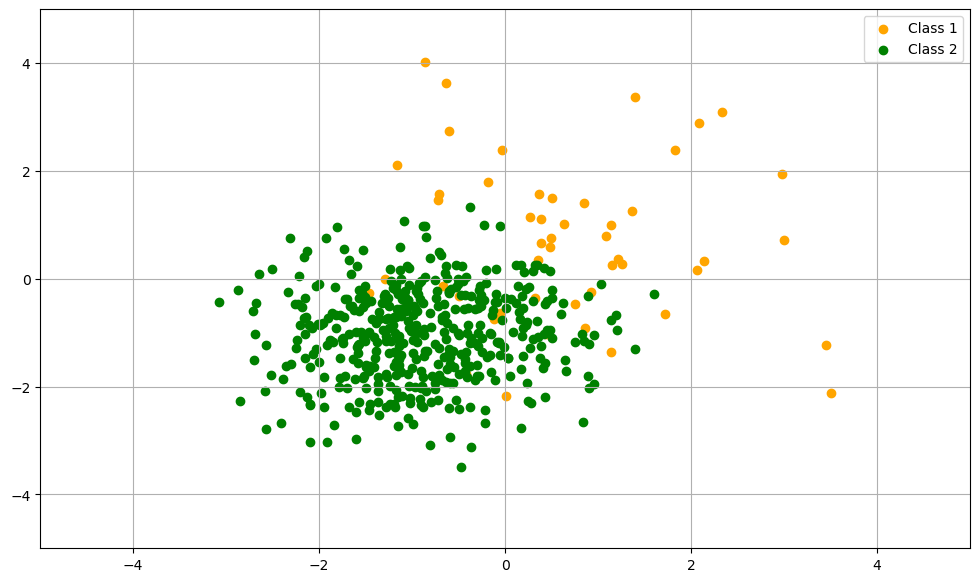

The training set accuracy for the GNB classifier is : 0.905
The test set accuracy for the GNB classifier is : 0.88


In [49]:
# Implement the BNB Classifier with Class Imbalanced Data.
train_BNB_classifier(X_train_imbalanced , t_train_imbalanced , X_1_imbalanced , X_2_imbalanced , X_test_imbalanced , t_test_imbalanced , scale = 5)


### Effect of Gaussian Noice.

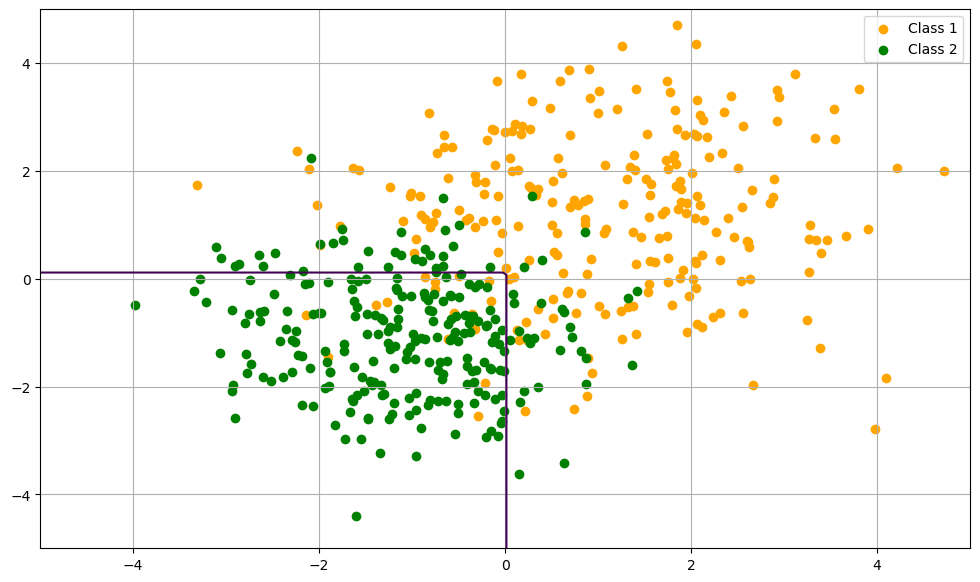

The training set accuracy for the GNB classifier is : 0.85
The test set accuracy for the GNB classifier is : 0.84


In [50]:
# Implement the BNB Classifier with Noisy Data (low).
train_BNB_classifier(X_train_low_noise , t_train_low_noise , X_1_low_noise , X_2_low_noise , X_test_low_noise , t_test_low_noise , scale = 5)


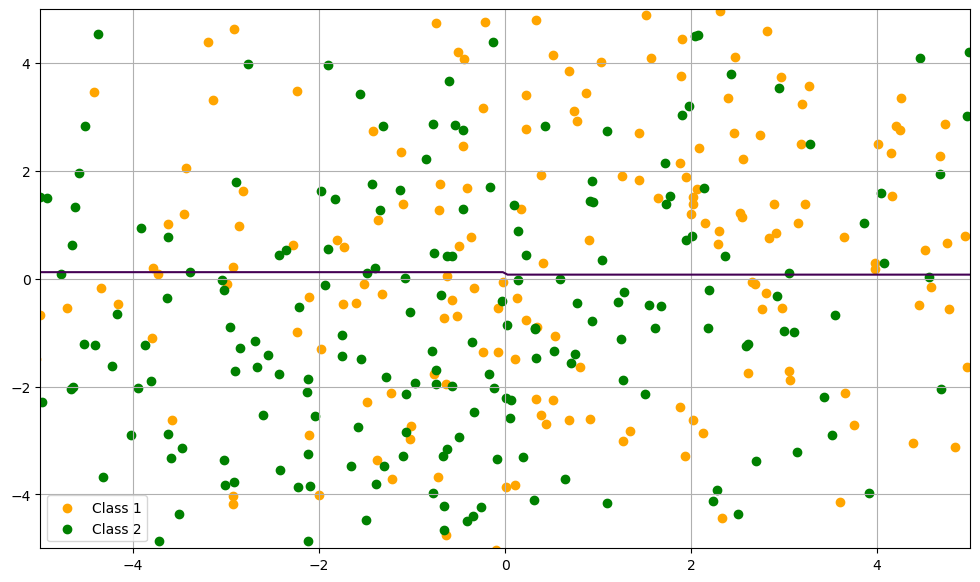

The training set accuracy for the GNB classifier is : 0.635
The test set accuracy for the GNB classifier is : 0.6


In [51]:
# Implement the BNB Classifier with Noisy Data (high).
train_BNB_classifier(X_train_high_noise , t_train_high_noise , X_1_high_noise , X_2_high_noise , X_test_high_noise , t_test_high_noise , scale = 5)


In [52]:
BNB_noise_accuracies = [] # Array to store accuracies after running 10 trials with different Noises 
for i in range(10):
    # Add Random Noise.
    X_1_noise , X_2_noise ,X_train_noise , t_train_noise ,  X_test_noise , t_test_noise = add_noise_to_dataset(X_1.copy() , X_2.copy() , var = low_noise)
    # Calculate and Store the accuracy.
    BNB_noise_accuracies.append(train_BNB_classifier(X_train = X_train_noise , t_train = t_train_noise , X_1 = X_1_noise , X_2 = X_2_noise , X_test = X_test_noise , t_test = t_test_noise , plot = 0)[0])

for i in range(10):
    # Add Random Noise.
    X_1_noise , X_2_noise ,X_train_noise , t_train_noise ,  X_test_noise , t_test_noise = add_noise_to_dataset(X_1.copy() , X_2.copy() , var = high_noise)
    # Calculate and Store the accuracy.
    BNB_noise_accuracies.append(train_BNB_classifier(X_train = X_train_noise , t_train = t_train_noise , X_1 = X_1_noise , X_2 = X_2_noise , X_test = X_test_noise , t_test = t_test_noise , plot = 0)[0])


### Impact of Gaussian Noice 

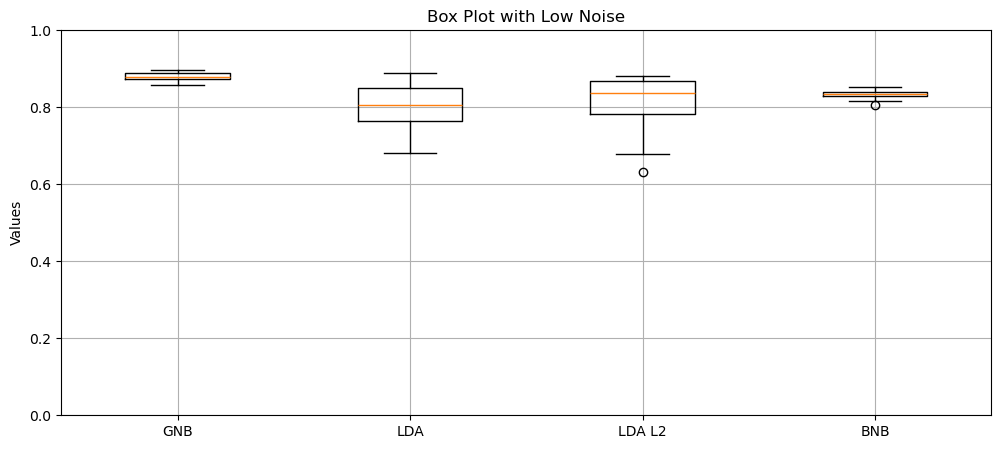

In [53]:
# Box Plot for the distributions of accuracies for different classifiers after adding noise

plt.figure(figsize = (12,5))
# Accuracies after adding noise
data = [GNB_noise_accuracies[:10],
        LDA_noise_accuracies[:10],
        L2_LDA_noise_accuracies[:10] ,
        BNB_noise_accuracies[:10]]

plt.boxplot(data, tick_labels=['GNB', 'LDA', 'LDA L2' , 'BNB'])
plt.title("Box Plot with Low Noise")
plt.ylabel("Values")
plt.ylim((0,1))
plt.grid()
plt.show()


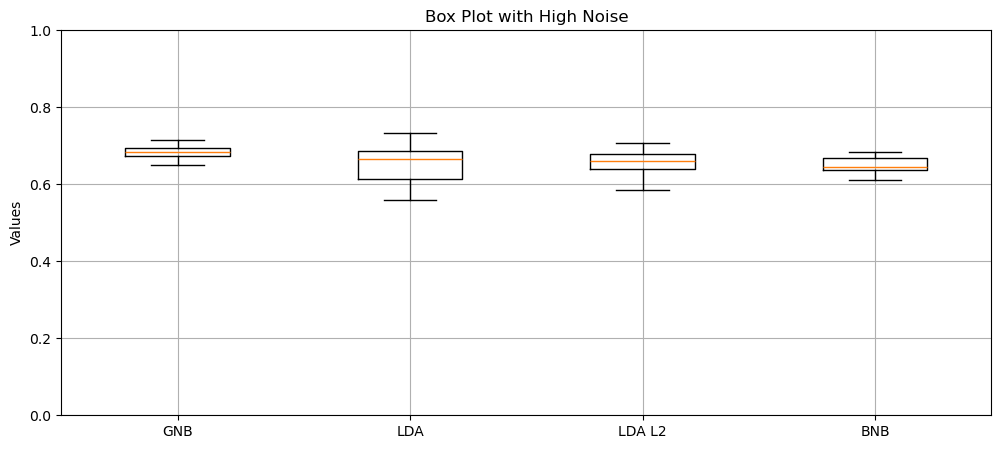

In [54]:
# Box Plot for the distributions of accuracies for different classifiers after adding noise

plt.figure(figsize = (12,5))
# Accuracies after adding noise
data = [GNB_noise_accuracies[10:],
        LDA_noise_accuracies[10:],
        L2_LDA_noise_accuracies[10:] ,
        BNB_noise_accuracies[10:]]

plt.boxplot(data, tick_labels=['GNB', 'LDA', 'LDA L2' , 'BNB'])
plt.title("Box Plot with High Noise")
plt.ylabel("Values")
plt.ylim(0,1)

plt.grid()
plt.show()

### Observations
- As expected on increasing the noise the accuracies of all the classifiers fall.
- Visually and from the plots we see that the GNB gives the best performance when the dataset has gaussian noice.
- The LDA classifiers' accuracy is sensititve to Gaussian Noice. Even with small amount of added noice the accuracies show higher variances when compared to the GNB and BNB classifiers.
- When compared in the order of median accuracies GNB > LDA L2 > LDA > BNB

### Robustess Analysis
- Gaussian Noice : The GNB classifier looks more robust to the gaussian noice which is also indicated in the bar plots. The boundries of LDA classifiers are sensitive to noise in the sense that the range in which the accuracies lie is wider. This means that these decision boundries may fluctuate drastically with measurement noice in the data. 

- Class Imbalance : In this we can see that the LDA classifiers and the BNB classifier predict all the samples as one class (the class having 90% samples) which make them less useful. The GNB classifier still tries to seperate the samples so this can be considered robust.

- Non Linear Seperability : GNB having quadratic decision boundry gives the best output with non-linearly seperable datasets. On the other hand LDA classifiers only give linear decision boundries . The BNB classifier on the other hand divides the space into four quadrants and classifies each one of them into one of the classes and this will lead to poor performances in the case of more complexly distributed data